## STOCHASTIC MODELING
MODULE 5 | LESSON 1


---


# **MARKOV MODELS**

|  |  |
|:---|:---|
|**Reading Time** |  50 minutes |
|**Prior Knowledge** |Linear Algebra, Maximum likelihood estimator, Monte Carlo  |
|**Keywords** |Markov Process, Markov chains, Transition Matrix


---

In this lesson, we introduce Markov chains in a reinforcement learning framework with Python. The idea is to understand the foundations of Markov chains to later on implement them in a financial setting. This lecture also represents the first building block in order to understand more complex reinforcement learning methods.*

In [1]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1121447627", h="3298dbabb7", width=700, height=450)

## **1. Markov property and Reinforcement learning (RL)**

### 1.1 The RL Setting

Machine learning provides automated methods that can detect patterns
in data and use them to achieve some tasks. Within ML methods, reinforcement learning (RL) is the task of learning how a decision-maker should take sequences of actions in order to optimize the cumulative rewards.

The general RL problem is formalized as a discrete time stochastic control problem. At each time step $t$, the environment is represented by a *state* $s_t\in\mathcal{S}$, where $\mathcal{S}$ represents the state space, i.e., all the possible situations where the agent can fall. Given $s_t$, the agent must take an action $a_t\in\mathcal{A}$ that implies (i) a reward $r_t\in\mathcal{R}$ for the agent, and (ii) a transition to state $s_{t+1}\in\mathcal{S}$.

Beginning at time $t=0$, the RL problem boils down to finding a sequence of actions $\{a_0,a_1,...,a_t,...\}$ that maximizes the cumulative rewards for the agent. We can model this leveraging Markov chains.


### 1.2 Markov property

We are going to consider the stochastic control process with the Markovian property.

**Definition**. A discrete time stochastic control process is Markovian (i.e., it has the Markov property) if
*   $\mathbb{P}(s_{t+1}|s_{t},a_{t})=\mathbb{P}(s_{t+1}|s_{t},a_{t},...,s_{0},a_{0})$
*   $\mathbb{P}(r_{t}|s_{t},a_{t})=\mathbb{P}(r_{t}|s_{t},a_{t},...,s_{0},a_{0})$

\
The Markov property means that the future of the process only
depends on the current observation, and the agent has no interest in looking at the full history. Before studying a fully fledged case of Reinforcement Learning, we are going to focus on the properties of random process with the Markov property and some specific finance applications.

## **2. Markov chains**

If the state space consists of countably many states, the Markov process is called a Markov chain, formally defined as follows:

A sequence of random variables $(S_0,S_1,S_2,...)$ is a Markov chain with state space $\mathcal{S}$ and transition matrix $P$ if, for all $t\geq 0$ and all sequences $(s_0,s_1,s_2,...,s_t,s_{t+1})$, we have that $\mathbb{P}(S_{t+1}|s_{t},s_{t-1},...,s_{1},s_{0})=\mathbb{P}(S_{t+1}|s_{t})$.



### 2.1 Homogeneous Markov chains

We say that a Markov chain with state space $\mathcal{S}=\{s_1,...,s_N\}$ is homogeneous if $\mathbb{P}(S_{t+1}=s_i | S_{t}=s_j)$ is constant for all $t$ and $(i,j)$. For homogeneous Markov chains, we can specify $\mathbb{P}(S_{t+1}=s_j | S_{t}=s_i) = p_{ij}$ and, then, the matrix $P(p_{ij})$ is the transition matrix for $S_t$, where it must satisfy that $\sum_i p_{ij} = 1$ for all $i$.

A Markov chain's transition matrix P is a stochastic matrix, i.e., a square matrix of non-negative terms in which the elements in each row sum to one.

*Note: Some authors opt to define the transition matrix $P$ as the matrix whose entries $p_{ij}$ denote the probability that the state changes from $j$ to $i$. We prefer the notation with the convention above as the most intuitive.*

We have described how the one-step-ahead realizations of a Markov chain depend on its current realizations. How do the further-ahead realizations of the chain depend also on current realizations? For instance, notice that
$$
\begin{align}
\mathbb{P}(s_{t+2}=s_j | s_{t}=s_i) & = \sum_{k=1}^N \mathbb{P}(s_{t+2}=s_j | s_{t+1}=s_k, s_{t+1}=s_i)\mathbb{P}(s_{t+1}=s_k | s_{t}=s_i) \\
& = \sum_{k=1}^N \mathbb{P}(s_{t+2}=s_j | s_{t+1}=s_k)\mathbb{P}(s_{t+1}=s_k | s_{t+1}=s_i) \\
& =  \sum_{k=1}^N p_{kj}p_{ik}
\end{align}
$$
Notice that this result yields the $(i,j)^{th}$ position of the squared transition matrix, $P^2$.

Following the same logic, letting $p_{ij}^n$ denote the $(i,j)^{th}$ position of matrix $P^n$:
$$
\begin{align}
\mathbb{P}(s_{t+m}=s_j | s_{t+n}=s_i) = p_{ij}^{m+n} = \sum_{k=1}^N p_{kj}^n p_{ik}^m
\end{align}
$$

### 2.2 Working example: A Two-state homogeneous Markov chain

Let $\mathcal{S}=\{s_1,s_2\}$, with $s_1\lt s_2$, $\mathbb{P}(S_{t+1}=s_1|s_{1}) = p$, and $\mathbb{P}(S_{t+1}=s_2|s_{2})= q$. Then, we can represent the transition matrix for this chain as
$$
\begin{align}
P = \begin{bmatrix}
p & 1-p \\
1-q & q
\end{bmatrix}
\end{align}
$$
If we multiply the transition matrix by the vector that represents the state space of the process, we obtain the expectation of the next period's state, conditional on each state. In our simple 2-state case:
$$
\begin{align}
\begin{bmatrix}
p & 1-p \\
1-q & q
\end{bmatrix}
\begin{bmatrix}
s_1 \\
s_2
\end{bmatrix}
=
\begin{bmatrix}
E(s_{t+1}|s_t = s_1) \\
E(s_{t+1}|s_t = s_2)
\end{bmatrix}
\end{align}
$$
Suppose that a process $X_t$ is such that $X_t = X_{t-1} + s_t$, where $s_t$ is the Markov process above. Let's simulate the process for some arbitrary parameters.

In [1]:
# Import libraries for later use

import matplotlib.pyplot as plt
import numpy as np
from numpy.random import rand, seed

Now, let's build our state vector, $S$, as well as the transition matrix, $P$, and the conditional mean vector:

In [2]:
N_STATES = 2
S = np.zeros((2, 1))
P = np.zeros((2, 2))

S[0] = -1
S[1] = 1

P[0, 0] = 0.55
P[0, 1] = 1.0 - P[0, 0]
P[1, 1] = 0.55
P[1, 0] = 1.0 - P[1, 1]

# Display the state vector
print("State vector:\n", S)
# Display the transition matrix
print("Transition matrix:\n", P)
# Display the conditional mean vector
S_condmean = np.dot(P, S)
print("Conditional mean vector:\n", S_condmean)

State vector:
 [[-1.]
 [ 1.]]
Transition matrix:
 [[0.55 0.45]
 [0.45 0.55]]
Conditional mean vector:
 [[-0.1]
 [ 0.1]]


With these tools, we can now chech how a Markov chain behaves by simulating the behavior of a random variable $x_t$ sampling from the Markov chain:

In [3]:
# Simulate a sequence from the Markov chain setup before

np.set_printoptions(precision=3, suppress=True)  # Just setting printout options
seed(12345)       # Setting random seed for replicability


LEN_HIST = 500  # We will simulate 500 realizations of X_t
states = np.zeros((LEN_HIST, 2), np.int8)    # Building up the empty matrices of states, values of X, and probabilities
Xarray = np.zeros(LEN_HIST)
Psim = np.zeros((2, 2))

# Defining dictionaries that link states and values

S_DICT = dict(
    [
        ("1",
            0,),
        ("2", 1),])
S_VAL = dict(
    [
        (
            "1",
            -1,
        ),
        ("2", 1),])

In [4]:
# Generate sequence of uniform random numbers

randarray = rand(LEN_HIST)

# Initialize process s_0, say at state 1 (0 in Python's vector notation)

states[0, :] = (S_DICT["1"], S_VAL["1"])

# Initial value for X_t (think, for example about the price of a stock today)

Xarray[0] = 75

In [5]:
# Simulate the behavior of the random variable sampling from the Markov chain

for tt in range(1, LEN_HIST):
    if P[states[tt - 1, 0], states[tt - 1, 0]] > randarray[tt]:   # Condition to stay in current state
        states[tt, :] = states[tt - 1, :]
    else:                                                         # Conditions to move on to another state
        if states[tt - 1, 0] == S_DICT["1"]:
            states[tt, :] = [S_DICT["2"], S_VAL["2"]]
        else:
            states[tt, :] = [S_DICT["1"], S_VAL["1"]]
    Xarray[tt] = Xarray[tt - 1] + states[tt, 1]
    Psim[states[tt - 1, 0], states[tt, 0]] = (
        1.0 + Psim[states[tt - 1, 0], states[tt, 0]]
    )

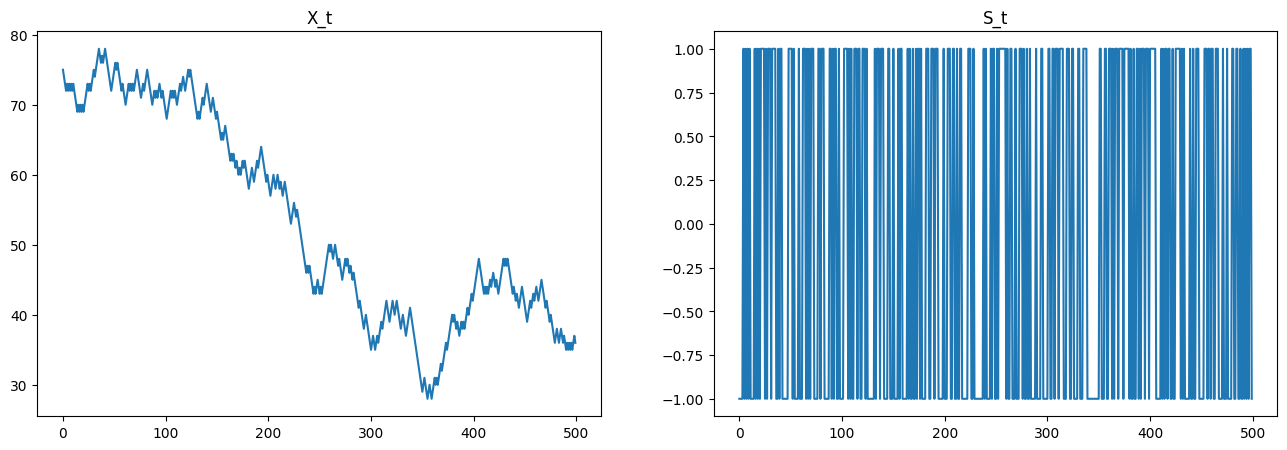

In [6]:
# Plot the evolution of the X_t and each of the states realized (S_t)

plt.subplot(1, 2, 1)
plt.plot(Xarray)
plt.title("X_t")

plt.subplot(1, 2, 2)
plt.plot(states[:, 1])
plt.title("S_t")

fig = plt.gcf()
fig.set_size_inches(16, 5)
plt.show()

### 2.3 Estimating Markov Transition Probabilities

From the previous very simple example one can see the power of Markov chains in modeling the behavior of a random variable under different regimes (e.g., stock prices under bull and bear markets).

When using these models for trading, even simple ones, we might be interesting in estimating how likely is that the random variable experiences a change of regime. In other words, how probable is that our stock continues to experience a bull (or bear) market? Conversely, how likely is that its trend changes? This is why estimating transition probabilities is going to provide useful information.

\
Suppose that we observe the realizations of a Markov chain and wish to estimate the probabilities of the transition matrix $P$. If $n_{ij}$ is the number of times that we observe a change from state $i$ to state $j$ and $N$ is the total number of states, then the estimated transition probabilities can be computed as:

\
$$
\begin{align}
\widehat{p}_{ij} = \frac{n_{ij}}{\sum_{k=1}^N n_{ik}}
\end{align}
$$

\
One can show that this expression corresponds to the Maximum Likelihood Estimator for $p_{ij}$. Let's verify that the Monte Carlo exercise yields the correct transition matrix.

In [7]:
# Compute estimated transition matrix from the previous Monte Carlo exercise
Pest = (Psim.T / np.sum(Psim, axis=1)).T

print(Pest)

[[0.565 0.435]
 [0.509 0.491]]


Note that we have estimated these using just 500 realizations (the original value we set for "LEN_HIST"). You can verify that as you increase this number the transition probabilities are going to be closer to the ones we calculated in section 2.2. Also, note this can take some time to run if you set a very high number for LEN_HIST.

### 2.4 Stationary distributions and absorbing states

Transition probabilities help us assess the probability of a change of states based on the history of the chain. But, how stable are these transition probabilities? In a classic Markov chain, we consider a stationary distribution.

\
Consider the matrix $P^n$, whose $(i,j)^{th}$ element is $p_{ij}^n = \mathbb{P}(s_{t+n}=s_j | s_{t}=s_i)$. If memory of the past dies out with increasing $n$, then we would expect the dependence of $p_{ij}^n$ on both n and i to disappear as $n→\infty$. This means that $P^n$ should converge to a limit as $n→\infty$ and that for each column $j$, its elements should all converge toward the same value $\pi_j$, and all its rows should be identical.

\
Notice that $p_{ij}^{n+1} = \sum_{k=1}^N p_{kj} p_{ik}^n$. Assuming convergence, this means that the limiting distribution as $n→\infty$ satisfies $\pi_{j}^{n+1} = \sum_{k=1}^N p_{kj} \pi_{k}$. In vector form:

\
$$
\begin{align}
\pi = \pi P ;\ \text{where}\ \pi=\{\pi_1,...,\pi_N\}, \pi_k\geq 0\  \text{and}\ \sum_k\pi_k = 1
\end{align}
$$

\
If the row-vector $\pi$ is taken as the initial probability distribution of the Markov chain, then $\pi = \pi P = \pi P^2= \pi P^3=...$, and we say that the chain is in steady state.

\
Under what conditions does convergence take place? Under what conditions is $\pi$ unique? While we are going to omit the details, convergence is essentially assured by the fact that $P$ is a stochastic matrix whose largest eigenvalue is one. Uniqueness is guaranteed under the property ergodicity. This means that, first, there is positive probability of traveling from any state to any other. Second, it means that the states are not partitioned into sets such that all state transitions occur cyclically from one set to another.

\
Let's perform a simple exercise to show this:

In [8]:
# Compute estimated stationary distribution from the Monte Carlo exercise
Pstat = [1.0 - np.sum(states[:, 0]) / LEN_HIST, np.sum(states[:, 0]) / LEN_HIST]

print(Pstat)

[np.float64(0.54), np.float64(0.46)]


In [9]:
# Compute the stationary distribution from the transition matrix with simple matrix multiplication

P2 = np.matmul(P, P)
print(P2)
P3 = np.matmul(P2, P)
print(P3)
P10 = np.linalg.matrix_power(P, 10)
print(P10)
P40 = np.linalg.matrix_power(P, 40)
print(P40)

[[0.505 0.495]
 [0.495 0.505]]
[[0.501 0.499]
 [0.499 0.501]]
[[0.5 0.5]
 [0.5 0.5]]
[[0.5 0.5]
 [0.5 0.5]]


In [10]:
# Sequential multiplication of a vector

p_stat = 0.5 * np.ones((2))
for t in range(1, 100):
    p_stat = np.dot(P.T, p_stat)

print(p_stat)

[0.5 0.5]


As you can see with this very simple example, probabilities tend to converge.

\
Finally, there is one more concept we should introduce regarding Markov chain before working with them in practice. This is the case of **absorbing Markov chains**.

\
**Absorbing Markov chains**

If a Markov chain is homogeneous, we say that state $i$ is absorbing if $p_{ii}=1$. That is, once the Markov chain $S_t$ enters an absorbing state, it stays there forever.

Absorbing Markov chains play a prominent role in Finance, for example, by identifying default as an absorbing state. This is precisely what we are going to do in the next lesson, implement a Markov model that incorporates firm default as an absorving state.

## Code Task: 
Write a function `is_markov(transition_matrix)` that checks if a given transition matrix is valid for a Markov chain.
A valid transition matrix must satisfy two conditions:

* All entries are non-negative.
* Each row sums to 1.

In [ ]:
import numpy as np

def is_markov(transition_matrix):
    """
    Checks if a matrix is a valid Markov transition matrix.
    
    Args:
        transition_matrix (np.ndarray): Square matrix
    
    Returns:
        bool: True if valid, False otherwise
    """
    # Your code here

## **4. Conclusion**

In this lesson, we have worked through the concept of a Markov Chain and its application to a simple credit rating case study. In the next lesson, we will put all these concepts into practice!

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
